In [2]:
from typing import TypedDict, Optional
from langgraph.graph import StateGraph, START, END

In [3]:
class QuadraticEquationState(TypedDict):
    a: int
    b: int
    c: int

    discriminant: Optional[float]
    equation: str
    result: Optional[str]

In [4]:
def show_eq(QuadraticEquationState):
    eq = f"{QuadraticEquationState['a']}x^2 + {QuadraticEquationState['b']}x + {QuadraticEquationState['c']} = 0"
    return {"equation": eq}

def calc_disc(QuadraticEquationState):
    a = QuadraticEquationState['a']
    b = QuadraticEquationState['b']
    c = QuadraticEquationState['c']
    discriminant = b**2 - 4*a*c
    return {"discriminant": discriminant}

In [5]:
graph = StateGraph(QuadraticEquationState)
graph.add_node('show_eq' , show_eq)
graph.add_node('calc_disc' ,  calc_disc)

In [6]:
def calc_real_roots(QuadraticEquationState):
    a = QuadraticEquationState['a']
    b = QuadraticEquationState['b']
    c = QuadraticEquationState['c']
    discriminant = QuadraticEquationState['discriminant']
    root1 = (-b + discriminant**0.5) / (2*a)
    root2 = (-b - discriminant**0.5) / (2*a)
    return {"result": f"Real roots: {root1}, {root2}"}

def calc_no_real_roots(QuadraticEquationState):
    return {"result": "No real roots"}

def calc_repeated_roots(QuadraticEquationState):
    a = QuadraticEquationState['a']
    b = QuadraticEquationState['b']
    root = -b / (2*a)
    return {"result": f"Repeated root: {root}"}

In [7]:
graph.add_node('real_roots', calc_real_roots)
graph.add_node('no_real_roots', calc_no_real_roots)
graph.add_node('repeated_roots', calc_repeated_roots)

In [9]:
def check_discriminant(QuadraticEquationState):
    discriminant = QuadraticEquationState['discriminant']
    if discriminant > 0:
        return 'real_roots'
    elif discriminant == 0:
        return 'repeated_roots'
    else:
        return 'no_real_roots'

In [10]:
graph.add_edge(START, 'show_eq')
graph.add_edge('show_eq', 'calc_disc')
graph.add_conditional_edges('calc_disc', check_discriminant)
graph.add_edge('real_roots', END)
graph.add_edge('no_real_roots', END)
graph.add_edge('repeated_roots', END)

In [11]:
workflow = graph.compile()

In [18]:
input_data = {
    "a": 1,
    "b": 2,
    "c": 1
    }
final_state = workflow.invoke(input_data)

In [19]:
print("Final Result:", final_state['result'])

Final Result: Repeated root: -1.0


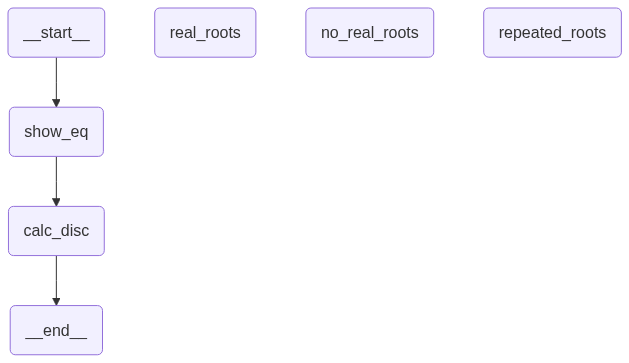

In [15]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())